## Time Series Analysis in Pandas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
temperature_df = pd.read_csv('https://drive.google.com/u/1/uc?id=1qh92_xjP1S6kOFjG8RGa7FTrJ3xdhwan&export=download')
temperature_df

,Country,City,Month,Day,Year,AvgTemperature
0,Algeria,Algiers,1,1,1995,64.2
1,Algeria,Algiers,1,2,1995,49.4
2,Algeria,Algiers,1,3,1995,48.8
3,Algeria,Algiers,1,4,1995,46.4
4,Algeria,Algiers,1,5,1995,47.9
...,...,...,...,...,...,...
251113,Zambia,Lusaka,1,18,2014,71.3
251114,Zambia,Lusaka,1,19,2014,77.5
251115,Zambia,Lusaka,1,20,2014,73.4
251116,Zambia,Lusaka,1,21,2014,73.1


**EDA: Exploratory Data Analysis**

1. We cannot use the time directly with "Month", "Day" and "Year" column
- Let's first create a datetime object for each row
- There are error values in these columns, fix them before the conversion

2. Set the values into index.  This turns the index to a specific type of index: DateTimeIndex.  DateTimeIndex allows us to look up records within specific time.
- Try to select records from 1997-03-28 to 1997-06-16

3. Plot the change in temperature of every city between 1997-03-28 and 1997-06-16
- Pivot the table so that there is 1 day per row, 1 city per column
- Plot the timeseries using `df.plot()` function

In [4]:
from datetime import datetime
def convert_time(row):
  try:
    return datetime(row['Year'], row['Month'], row['Day'])
  except:
    return datetime(row['Year'], 2, 29)

temperature_df['datetime'] = temperature_df.apply(convert_time, axis=1)

## 1. Regular time interval

For all timeseries modeling, we need our data to have regular time interval:
- per day
- per hour
- per minute



**resample()**

resample() can bin values into regular time intervals. It is used to fix 2 problems:

1. irregular time interval (e.g. server logs)
2. missing data (e.g. some day is missing in a per-day series)

Since `resample` is equivalent to `group by` a regular time interval, it is used similar to `groupby()`: we must follow `resample()` with an aggregation function.

Task:
- Resample the *Banjul* temperature so that we create rows for the missing dates

In [5]:
# Your code here

resampled = temperature_df[temperature_df.City == "Banjul"].set_index("datetime")['AvgTemperature'].resample("1d").mean()

In [8]:
x = temperature_df[temperature_df.City == "Banjul"].set_index("datetime")
x

,Country,City,Month,Day,Year,AvgTemperature
datetime,,,,,,
1995-01-01,Gambia,Banjul,1,1,1995,76.5
1995-01-02,Gambia,Banjul,1,2,1995,70.3
1995-01-03,Gambia,Banjul,1,3,1995,74.7
1995-01-04,Gambia,Banjul,1,4,1995,73.3
1995-01-05,Gambia,Banjul,1,5,1995,73.8
...,...,...,...,...,...,...
2020-05-09,Gambia,Banjul,5,9,2020,77.6
2020-05-10,Gambia,Banjul,5,10,2020,75.6
2020-05-11,Gambia,Banjul,5,11,2020,76.3


In [ ]:
x.loc['1995-02-01': '1995-03-01']

In [16]:
pd.DataFrame([[1,2], [3, 4], [3, 4], [3, 4], [3, 4], [3, 4], [3, 4]]).iloc[3:6].index

RangeIndex(start=3, stop=6, step=1)

In [11]:
pd.DataFrame([[1,2], [3, 4]]).index

RangeIndex(start=0, stop=2, step=1)

In [12]:
pd.DataFrame([[1,2], [3, 4]], index=["a", "b"])

,0,1
a,1,2
b,3,4


In [13]:
pd.DataFrame([[1,2], [3, 4]], index=["a", "b"]).index

Index(['a', 'b'], dtype='object')

**Fill empty data**

When dealing with missing values, we have some options:
1. Ignore the whole record
2. Fill the record
*   `.fillna()`       # Fill na with a value we like
*   `.ffill()`        # Fill with the last seen value
*   `.interpolate()`  # Fill with interpolated value



<Axes: xlabel='datetime'>

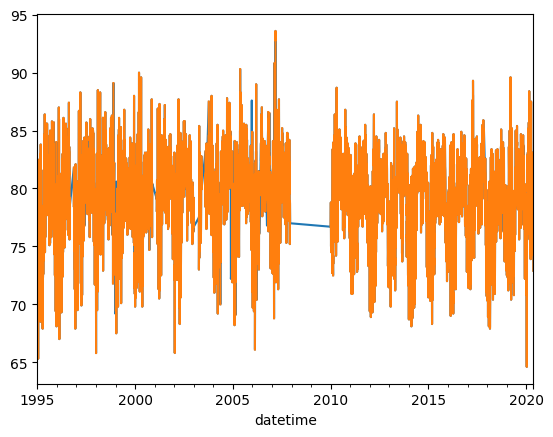

In [34]:
# Your code here


resampled.interpolate().plot()
resampled.plot()

## 2. Smoothen

`.rolling()` is pandas's version of rolling window or moving average.

- It can be used to calculate rolling sum or rolling average
- Similar to group by, after `rolling()`, we need an aggregation function

<Axes: xlabel='datetime'>

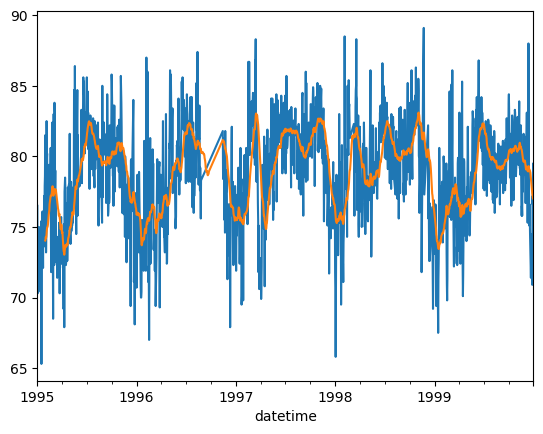

In [39]:
# Smoothen

resampled.interpolate()[:365 * 5].plot()

resampled.interpolate()[:365 * 5].rolling(30).mean().plot()

## 3. Stationarity

A time series is stationary when
1. The standard deviation remain the same all the time
2. The mean remain the same all the time

A lot of models requires a time seires to be stationary.

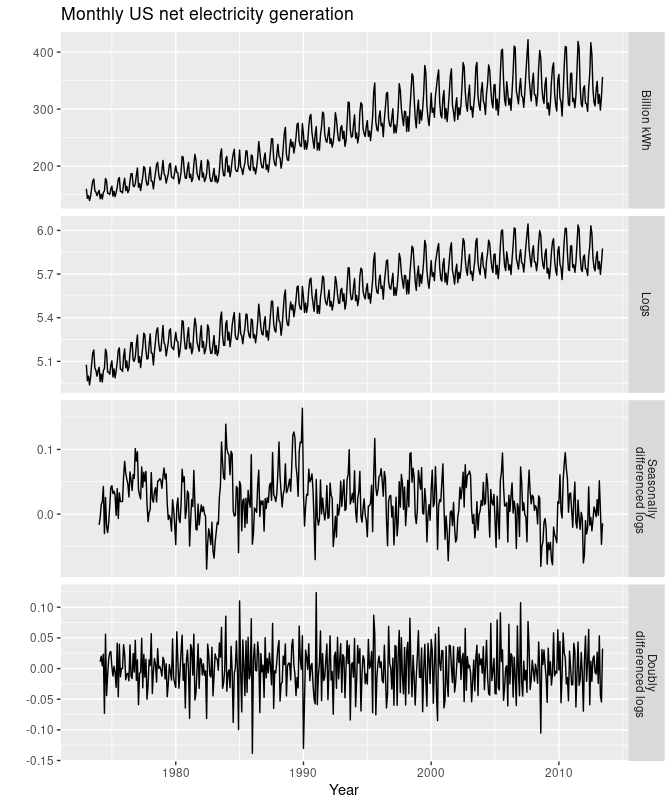

### 3.1 Hypothesis testing

1. For every statistical testing, we define
> H0: Null hypothesis<br>
> H1: Alternate Hypothesis<br>

2. Then we compare the p-value with our target confidence interval.
> p-Value < 0.05 == Satisfying CI at 95%<br>
> p-Value < 0.01 == Satisfying CI at 99%<br>

3. At the situation when CI is satisfied, we reject H0, the null hypothesis.


4. In ADF:
> H0: The time series is non-stationary<br>
> H1: The time series is stationary<br>

5. For example if the p-Value is 0.03, we say
> At 95% CI, we reject H0.  <br>
> Same to say: we think the time series is stationary with 95% confidence.


**Task**

Check if the time series is stationary.

1. Visualize the rolling mean and rolling std
2. Perform an Augmented Dickey-Fuller (ADF) test


In [ ]:
# Your code here
